In [38]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.visualization import astropy_mpl_style, quantity_support
plt.style.use(astropy_mpl_style)
quantity_support() 
import astropy.units as u
from astropy.time import Time
from datetime import datetime, timedelta
from astropy.coordinates import SkyCoord, EarthLocation, AltAz
import math
import astroplan as apl
import seaborn as sns
import pandas as pd
import skyfield.api
from pytz import timezone
import seaborn as sns
import pandas as pd
from random import randrange
sns.set_theme(style="ticks")
KECK_LAT = 19.8260 #[deg]
KECK_ELEVATION = 4.1449752 # km
RADIUS_EARTH = 6378.1000 # km
ATMOSPHERE_HEIGHT = 50.000 # km
KECK_LONG = 360 - 155.4747 

d1 = datetime.strptime('1/1/1990 1:30 PM', '%m/%d/%Y %I:%M %p')
d2 = datetime.strptime('1/1/2039 4:50 AM', '%m/%d/%Y %I:%M %p')

def random_date(start, end):
    """
    This function will return a random datetime between two datetime 
    objects.
    """
    delta = end - start
    int_delta = (delta.days * 24 * 60 * 60) + delta.seconds
    random_second = randrange(int_delta)
    return hawaii.localize(start + timedelta(seconds=random_second))

def date_to_juld(date):
    return (date.timestamp() / 86400) + 2440587.5 #do not offset
    #return (date.timestamp() / 86400)

def get_gmt(date=None):
    if date is None:
        date = datetime.now()
    JD = date_to_juld(date)
    T = (JD - 2451545) / 36525
    ThetaGMST = 67310.54841 + (876600 * 3600 + 8640184.812866) * T + .093104 * (T**2) - (6.2 * 10**-6) * (T**3)
    ThetaGMST = (ThetaGMST % (86400 * (ThetaGMST / abs(ThetaGMST))) / 240) % 360

    return ThetaGMST

def cosd(deg):
    return np.cos(math.pi / 180 * deg)

def sind(deg):
    return np.sin(math.pi / 180 * deg)

def tand(deg):
    return np.tan(math.pi / 180 * deg)

def ra_dec_to_alt_az(ra, dec, date=None):
    if date is None:
        date = datetime.now()
    lngLatEl = { 'lng': KECK_LONG, 'lat': KECK_LAT, 'ele': KECK_ELEVATION }
    hourAngle = (get_gmt(date) + lngLatEl['lng'] - ra) % 360
    tanAzNum = sind(hourAngle)
    tanAzDen = cosd(hourAngle) * sind(lngLatEl['lat']) - tand(dec) * cosd(lngLatEl['lat'])
    az = np.arctan(tanAzNum/ tanAzDen) + math.pi
    sinEl = sind(lngLatEl['lat']) * sind(dec) + cosd(lngLatEl['lat']) * cosd(dec) * cosd(hourAngle)
    el = np.arcsin(sinEl)
    return [(180 / math.pi * el), (180 / math.pi * az)]


hawaii = timezone('US/Hawaii')
loader = skyfield.api.Loader ('./')
ts = loader.timescale()
solar_system = loader ('de421.bsp')
earth = solar_system['earth']
wmko_skyfield = earth + skyfield.api.Topos (KECK_LAT, (KECK_LONG-360), elevation_m=KECK_ELEVATION*1000)


def skyfield_alt_az(ra, dec, date):
    tgt = skyfield.api.Star(ra_hours=ra/15, dec_degrees=dec)
    time = ts.from_datetime(date)
    astrometric = wmko_skyfield.at(time).observe(tgt)
    alt, az, _ = astrometric.apparent().altaz()
    return alt.degrees, az.degrees

ra = 10.0
dec = 10.0
date = hawaii.localize(datetime.now())

sky_alt_az = skyfield_alt_az(ra, dec, date)
py_alt_az = ra_dec_to_alt_az(ra, dec, date)

keck = EarthLocation(lat=KECK_LAT*u.deg, lon=KECK_LONG*u.deg, height=KECK_ELEVATION*u.km)
coord = SkyCoord(ra=ra * u.degree, dec=dec * u.degree, frame='icrs')

#coord = SkyCoord(ra * u.hourangle, dec * u.deg, frame="icrs")
target = apl.FixedTarget(name='tgt', coord=coord)
#time = Time(date +timedelta(hours=10))
time = Time(date)
t = ts.from_datetime(date)
ap_alt_az = coord.transform_to(AltAz(obstime=time,location=keck))

keckap = apl.Observer.at_site("W. M. Keck Observatory")
altaz = keckap.altaz(date, target, grid_times_targets=True)

print(date)
print(t.astimezone(hawaii))
print(py_alt_az[0])
print(ap_alt_az.alt.value)
print(altaz.alt.value[0][0])
print(sky_alt_az[0])

2024-04-10 11:09:02.795257-10:00
2024-04-10 11:09:02.795257-10:00
77.12244162148079
77.02669901057891
77.02266246150509
77.02677083378609


In [169]:
def alternate_finite(n: int):
    m = n // 2
    sign = 1
    for i in range(n):
        m = m + i * sign
        yield m
        sign *= -1
        
def binary_finite_recursive(n, sign=1):
    m = n // 2
    if n==0: return 
    else:
        return binary_finite_recursive(n + m // 2 * -1*sign)

def binary_search_recursive(arr, sign=1):
    # split array in two and search both ends
    mid = len(arr) // 2
    el = arr.pop(mid)
    print(el)
    if not len(arr): # exit
        #print(el)
        return
    #print(arr)
    if sign==-1:
        print('going left')
        valL = binary_search_recursive(arr[:mid+1], -1*sign)
    else:
        print('going right')
        valR = binary_search_recursive(arr[mid-1:], -1*sign)
        
def my_fun(arr, f):
    nxt = len(arr) // 2
    cum = 0
    while len(arr):
        el = arr.pop(nxt)
        if f(el):
            cum += 1
            nxt += 1
        else:
            nxt = np.random.uniform(0, len(arr))
    return cum
        
        
def binary_finite(n:int):
    m = n
    sign = 1
    for i in range(n):
        m = m // 2 + i * sign
        yield m
        sign *= -1


def zigzag_finite(arr) -> list:
    return [arr[i] for i in binary_finite(len(arr))]

# for idx, date in enumerate(zigzag_finite(range(10))):
#     print(f"{idx}:{date}")
    
# binary_search_recursive([x for x in range(10)])

my_fun([x for x in range(10)], lambda x: np.random.choice([1, 0]))

TypeError: 'float' object cannot be interpreted as an integer

In [252]:

nightlyTimes = [x for x in range(10)]
predicate = lambda *args, time: np.random.choice([True, False])
args = (1,2,3)
def smart_search(nightlyTimes, predicate, args, cum=0, th=3, stepSize=1):
    """searches random times until it finds an observable time,
    then it searches for adjacent elements
    """
    while len(nightlyTimes):
        nxt = np.random.choice(range(len(nightlyTimes)), replace=True)
        if not nxt >= len(nightlyTimes):
            time = nightlyTimes.pop(nxt)
        observable = predicate(*args, time=time)
        if observable: 
            cum += stepSize
            if cum>=th:
                return True
            n = np.random.choice([-1,1])
            if nxt + n > len(arr):
                nxt -= n
            else:
                nxt += n
        else:
            nxt = np.random.choice(range(len(nightlyTimes)), replace=True)
    return False

my_fun(nightlyTimes, predicate, args, cum=0, th=5, stepSize=1)

not observable, next try
1
2
3
4
5


True

In [237]:
1//2

0

In [78]:
def iter_from_middle(lst):
    try:
        middle = len(lst)//2
        yield lst[middle]

        for shift in range(1, middle+1):
            # order is important!
            yield lst[middle - shift]
            yield lst[middle + shift]
    except IndexError: # occures on lst[len(lst)] or for empty list
        raise StopIteration
        
for date in iter_from_middle(range(6)):
    print(date)

3
2
4
1
5
0


RuntimeError: generator raised StopIteration

In [68]:
dates = np.arange(d1, d2, timedelta(hours=24*30)).astype(datetime)

dates = np.array([ hawaii.localize(x) for x in dates ])
tgt = skyfield.api.Star(ra_hours=ra/15, dec_degrees=dec)
#time = ts.from_datetime(dates)
times = [ts.from_datetime(x) for x in dates]
astrometric = wmko_skyfield.at(times).observe(tgt)
alt, az, _ = astrometric.apparent().altaz()

ValueError: please provide the at() method with a Time instance as its argument, instead of the value [<Time tt=2447893.4798285183>, <Time tt=2447923.4798285183>, <Time tt=2447953.4798285183>, <Time tt=2447983.4798285183>, <Time tt=2448013.4798285183>, <Time tt=2448043.4798285183>, <Time tt=2448073.4798285183>, <Time tt=2448103.4798285183>, <Time tt=2448133.4798285183>, <Time tt=2448163.4798285183>, <Time tt=2448193.4798285183>, <Time tt=2448223.4798285183>, <Time tt=2448253.4798285183>, <Time tt=2448283.4798400924>, <Time tt=2448313.4798400924>, <Time tt=2448343.4798400924>, <Time tt=2448373.4798400924>, <Time tt=2448403.4798400924>, <Time tt=2448433.4798400924>, <Time tt=2448463.4798400924>, <Time tt=2448493.4798400924>, <Time tt=2448523.4798400924>, <Time tt=2448553.4798400924>, <Time tt=2448583.4798400924>, <Time tt=2448613.4798400924>, <Time tt=2448643.4798400924>, <Time tt=2448673.4798400924>, <Time tt=2448703.4798400924>, <Time tt=2448733.4798400924>, <Time tt=2448763.4798400924

In [59]:
len(dates[0])

TypeError: object of type 'datetime.datetime' has no len()

In [2]:
%%timeit
skyfield_alt_az(ra, dec, date)

3.32 ms ± 537 µs per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [3]:
%%timeit
ra_dec_to_alt_az(ra, dec, date)

3.81 µs ± 148 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)


In [4]:
%%timeit
coord.transform_to(AltAz(obstime=Time(date, scale='utc'),location=keck))

3.12 ms ± 35.6 µs per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [5]:
%%timeit
keckap.altaz(date, target, grid_times_targets=True)

4.78 ms ± 899 µs per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [42]:
data = []
for _ in range(10**3):
    date = random_date(d1, d2)
    ra = np.random.uniform(0, 360)
    dec = np.random.uniform(-90, 90)
    coord = SkyCoord(ra=ra * u.degree, dec=dec * u.degree, frame='icrs')
    target = apl.FixedTarget(name='tgt', coord=coord)
    time = Time(date)
    ap_alt_az = coord.transform_to(AltAz(obstime=time,location=keck))
    py_alt_az = ra_dec_to_alt_az(ra, dec, date)
    sky_alt_az = skyfield_alt_az(ra, dec, date)
    
    datum = {
        'ra': ra, 'dec': dec, 'date': date,
        'ap_az': ap_alt_az.az.value, 'ap_alt': ap_alt_az.alt.value,
        'py_alt': py_alt_az[0], 'py_az': py_alt_az[1],
        'sky_alt': sky_alt_az[0], 'sky_az': sky_alt_az[1],
        'py_err': py_alt_az[0] - ap_alt_az.alt.value,
        'alt_err': sky_alt_az[0] - ap_alt_az.alt.value,
        'az_err': sky_alt_az[1] - ap_alt_az.az.value,
    }
    data.append(datum)

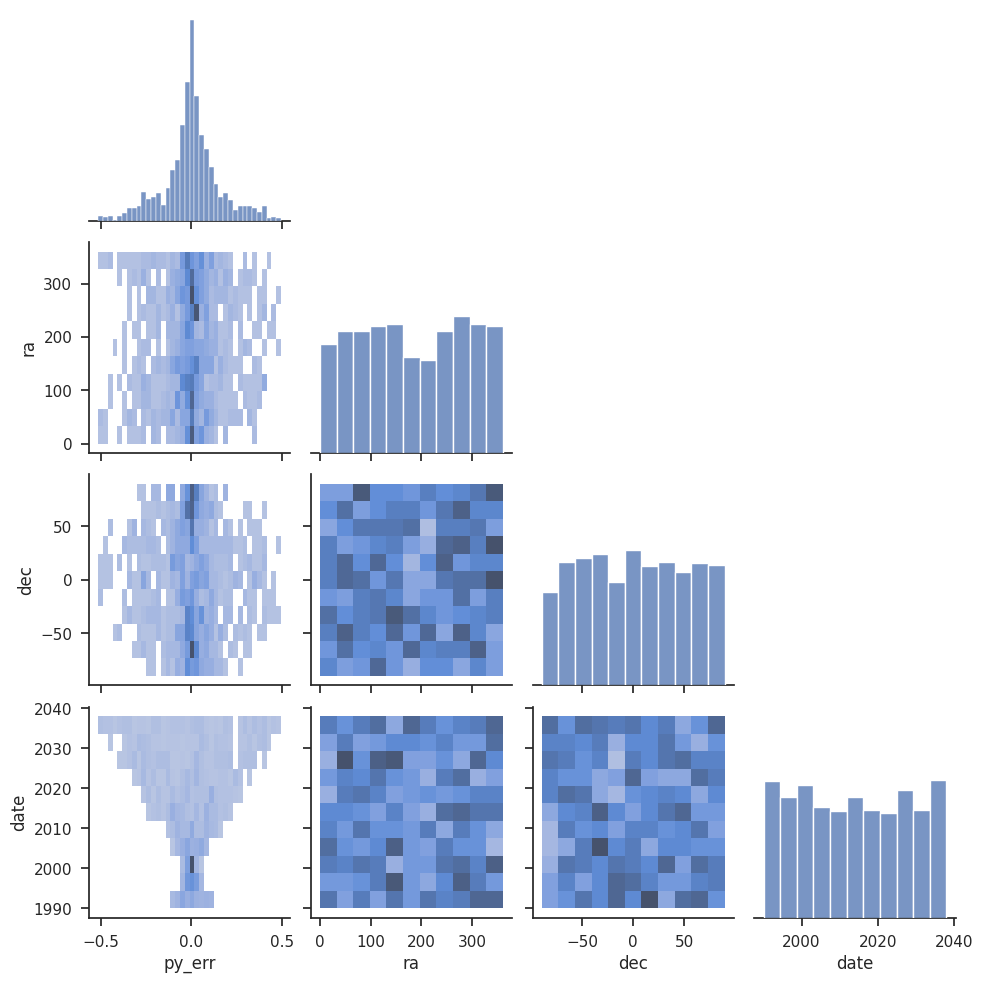

In [43]:
df = pd.DataFrame(data)
df = df[['py_err', 'ra','dec', 'date']]
df["date"] = df["date"].dt.year
sns.pairplot(df, kind="hist", corner=True)

In [69]:
df.head()

,alt_err,ra,dec,date
0,35.966486,123.932968,-26.622020,2027
1,9.410291,130.733949,-68.772031,2037
2,-1.869306,181.250230,-52.673705,2010
3,36.717617,176.406206,40.601354,2013
4,-9.777551,211.090076,81.859067,2011
